In [1]:
import pickle
from collections import defaultdict
from experiments_vllm import *
from config_synthetic_workloads import *
from trace_analysis import *

In [2]:
# Get test data: prompts from synthetic workloads
with open(workloads_file, 'rb') as file:
    workloads = pickle.load(file)

# Get results
with open(results_file, 'rb') as file:
    workload_results = pickle.load(file)

# Remove any failed runs
#workloads = {k: workloads[k] for k in workloads.keys() if workloads[k] is not None}

workload_lengths = list(workloads.keys())
workload_alphas = list(workloads[workload_lengths[0]].keys())
workload_length = workload_lengths[0]
workload_prompts = {alpha:workloads[workload_length][alpha]['prompts_formatted'] for alpha in workload_alphas}
trace_paths = {}
for i, alpha in enumerate(workload_alphas):
    if workload_results[alpha] is not None: # ignore failed runs
        trace_id_alpha = trace_id + f'_alpha{i}'
        trace_paths[alpha] = trace_dir + trace_id_alpha
workload_alphas = list(trace_paths.keys()) # Update, ignoring failed runs

In [3]:
# Analyze all traces
trace_results = {a: summarize(trace_paths[a]) for a in workload_alphas}

In [4]:
# Save results
results_file = f'./vllm_benchmarking/results_syntheticworkloads_{trace_id}.pkl'
analysis_file = trace_dir + 'analysis_' + trace_id + '.pkl'
with open(analysis_file, 'wb') as file:
    pickle.dump(trace_results, file)

In [17]:
def plot_traces(trace_results):
    x = list(trace_results.keys())
    rows = [trace_results[k] for k in x]
    y1 = [r["max_over_mean"] for r in rows]
    y2 = [r["mean_over_ranks_us"] for r in rows]

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Plot 1: max over mean
    ax = axes[0][0]
    ax.plot(x, y1, 'o-', color='b')
    ax.set_title('Max over Mean Fused MoE Kernel Time over Ranks vs. Alpha')
    ax.set_xlabel('Load Imbalance (Parameterized by Alpha)')
    ax.set_ylabel('Max / Mean')

    # Plot 2: mean over ranks
    ax = axes[0][1]
    ax.plot(x, y2, 'o-', color='b')
    ax.set_title('Mean Fused MoE Kernel Time over Ranks vs. Alpha')
    ax.set_xlabel('Load Imbalance (Parameterized by Alpha)')
    ax.set_ylabel('Mean Kernel Time (us)')

    plt.tight_layout()
    plt.show()

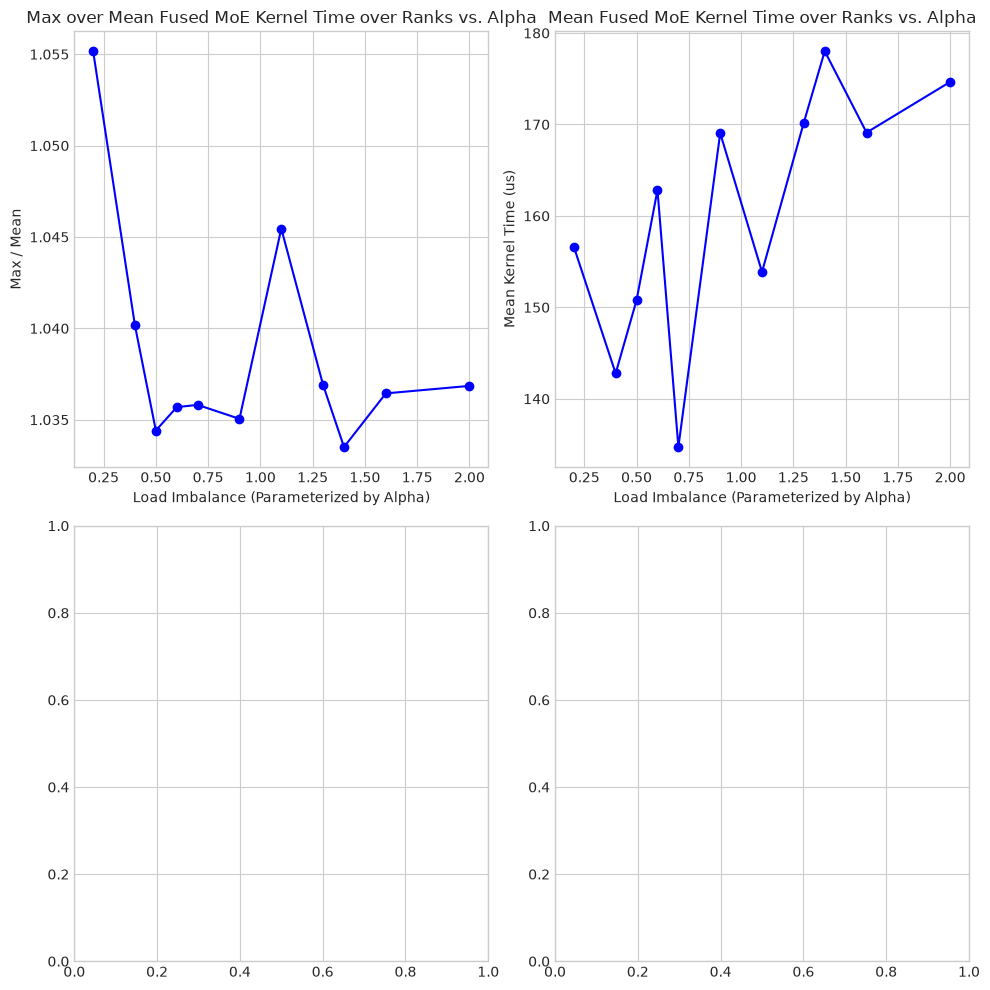

In [18]:
plot_traces(trace_results)

In [20]:
steps = {k:trace_results[k]['steps'] for k in workload_alphas}
calls_per_rank = {k:trace_results[k]['calls_per_rank'] for k in workload_alphas}

In [21]:
steps

{0.2: 285,
 0.4: 408,
 0.5: 329,
 0.6: 318,
 0.7: 446,
 0.9: 448,
 1.1: 643,
 1.3: 359,
 1.4: 244,
 1.6: 263,
 2.0: 259}

In [22]:
calls_per_rank

{0.2: 13680,
 0.4: 19584,
 0.5: 15792,
 0.6: 15264,
 0.7: 21408,
 0.9: 21504,
 1.1: 30864,
 1.3: 17232,
 1.4: 11712,
 1.6: 12624,
 2.0: 12432}